# Prompt Property Evaluation for Intelligent LLM Routing

This notebook explores and evaluates various properties of user prompts that can be used to make intelligent routing decisions between different Large Language Models (LLMs). The goal is to analyze prompt characteristics and develop a smart routing system that optimizes for cost, speed, and quality based on the specific requirements of each prompt.

## Table of Contents
1. [Introduction and Setup](#introduction)
2. [Prompt Property Framework](#framework)
3. [Dataset Creation](#dataset)
4. [Complexity Analysis](#complexity)
5. [Property Distribution Analysis](#analysis)
6. [Routing Strategy Comparison](#routing)
7. [Cost and Performance Analysis](#cost)
8. [Real-World Scenario Testing](#scenarios)
9. [Rule-Based Model Performance Evaluation](#metrics)


## 1. Introduction and Setup <a id="introduction"></a>

Smart routing of prompts to different LLMs can significantly optimize cost, latency, and output quality. This notebook analyzes various prompt properties to build a smart routing system for Azure OpenAI models.


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../src')

from prompt_analyzer import PromptAnalyzer
# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully")
print("📊 Ready for prompt property evaluation")


✅ All libraries imported successfully
📊 Ready for prompt property evaluation


## 2. Prompt Property Framework <a id="framework"></a>
We'll evaluate prompts across multiple dimensions to make smart routing decisions:

### Key Properties:
- **Complexity**: Simple, Moderate, Complex
- **Domain**: General, Code, Math, Creative, Analysis, Translation
- **Length**: Token count and word count
- **Features**: Code presence, mathematical content, questions
- **Urgency**: Real-time requirements
- **Context**: Multi-turn vs single-turn conversations


In [2]:
analyzer = PromptAnalyzer()

print("🤖 Available LLM Models and Configurations:")
print("=" * 50)

for model_name in analyzer.list_available_models():
    config = analyzer.get_model_info(model_name)
    print(f"\n📍 {model_name.upper()}")
    
    print(f"   💰 Pricing per 1K tokens:")
    print(f"      Input: ${config['input_cost_per_1k_tokens']:.3f}")
    print(f"      Output: ${config['output_cost_per_1k_tokens']:3f}")
    
    if 'cached_input_cost_per_1k_tokens' in config and config['cached_input_cost_per_1k_tokens']:
        print(f"      Cached Input: ${config['cached_input_cost_per_1k_tokens']:.4f}")
    
    if 'batch_input_cost_per_1k_tokens' in config and config['batch_input_cost_per_1k_tokens']:
        print(f"      Batch Input: ${config['batch_input_cost_per_1k_tokens']:.4f}")
        print(f"      Batch Output: ${config['batch_output_cost_per_1k_tokens']:.4f}")
    
    print(f"   ⚡ Avg response time: {config['avg_response_time_ms']}ms")
    print(f"   📊 Max tokens: {config['max_tokens']:,}")
    print(f"   🎯 Best for: {', '.join(config['use_cases'])}")
    print(f"   🧠 Complexity threshold: {config['complexity_threshold'].value}")
    
    avg_cost = (config['input_cost_per_1k_tokens'] + config['output_cost_per_1k_tokens']) / 2
    print(f"   📈 Average cost: ${avg_cost:.4f} per 1K tokens")

🤖 Available LLM Models and Configurations:

📍 O3
   💰 Pricing per 1K tokens:
      Input: $0.002
      Output: $0.008000
      Cached Input: $0.0005
      Batch Input: $0.0010
      Batch Output: $0.0040
   ⚡ Avg response time: 5000ms
   📊 Max tokens: 100,000
   🎯 Best for: complex_reasoning, advanced_analysis, stem_problems, accuracy_priority
   🧠 Complexity threshold: complex
   📈 Average cost: $0.0050 per 1K tokens

📍 GPT-4O-MINI
   💰 Pricing per 1K tokens:
      Input: $0.001
      Output: $0.002400
      Cached Input: $0.0003
   ⚡ Avg response time: 400ms
   📊 Max tokens: 16,384
   🎯 Best for: simple_qa, chat, high_volume, speed_priority
   🧠 Complexity threshold: simple
   📈 Average cost: $0.0015 per 1K tokens

📍 O4-MINI
   💰 Pricing per 1K tokens:
      Input: $0.001
      Output: $0.004400
      Cached Input: $0.0003
      Batch Input: $0.0006
      Batch Output: $0.0022
   ⚡ Avg response time: 2000ms
   📊 Max tokens: 16,384
   🎯 Best for: balanced_tasks, cost_efficient, genera

## 3. Dataset Creation <a id="dataset"></a>

Creation of a dataset of prompts that cover various scenarios, domains, and complexity levels.


In [3]:
test_prompts = {
    "Simple General Queries": [
        "What is the weather like today?",
        "Tell me a joke.",
        "What time is it?",
        "Hello, how are you?",
        "What is the capital of France?"
    ],
    
    "Code Generation": [
        "Write a Python function to sort a list of numbers.",
        "Create a REST API endpoint using FastAPI for user authentication.",
        "Generate a React component for a responsive navigation bar.",
        "Write SQL queries to find the top 10 customers by revenue.",
        "Implement a binary search algorithm in JavaScript.",
        "Create a Dockerfile for a Node.js application with multi-stage builds."
    ],
    
    "Mathematical Problems": [
        "Solve the equation: 2x + 5 = 15",
        "Calculate the area of a circle with radius 7.5 meters.",
        "Find the derivative of f(x) = x³ + 2x² - 5x + 3",
        "What is 15% of 240?",
        "Solve this system of equations: 3x + 2y = 12, x - y = 1"
    ],
    
    "Creative Writing": [
        "Write a short story about a robot learning to paint.",
        "Create a poem about artificial intelligence.",
        "Design a creative marketing campaign for a sustainable fashion brand.",
        "Write a dialogue between two AI systems discussing ethics.",
        "Create a fantasy world with unique magic systems and cultures."
    ],
    
    "Complex Analysis": [
        "Analyze the performance implications of using a binary search tree vs a hash table for different use cases.",
        "Compare and contrast the economic impacts of renewable energy adoption across developing and developed nations.",
        "Evaluate the ethical implications of AI-driven hiring processes in large corporations.",
        "Assess the security vulnerabilities in microservices architecture and propose mitigation strategies.",
        "Analyze the correlation between social media usage patterns and mental health outcomes in teenagers."
    ],
    
    "Translation Tasks": [
        "Translate 'Hello, how are you?' to Spanish, French, and German.",
        "Convert this technical documentation from English to Japanese.",
        "Explain the meaning of 'schadenfreude' in English.",
        "Translate this legal contract clause while preserving its legal meaning."
    ],
    
    "Urgent/Real-time Queries": [
        "URGENT: How do I stop a memory leak in my production Node.js app?",
        "Quick question: What's the fastest way to deploy a hotfix?",
        "I need immediate help with a database connection issue.",
        "Emergency: My API is returning 500 errors, what should I check first?"
    ],
    
    "Long Context Queries": [
        """Given the following requirements for an e-commerce platform:
        - User authentication and authorization
        - Product catalog management
        - Shopping cart functionality
        - Payment processing integration
        - Order tracking and management
        - Inventory management
        - Customer reviews and ratings
        - Search and filtering capabilities
        - Admin dashboard for analytics
        - Mobile responsiveness
        - Performance optimization for high traffic
        - Security compliance (PCI DSS)
        
        Design a comprehensive system architecture using Azure services that addresses all these requirements while ensuring scalability, security, and cost-effectiveness. Include database design, API structure, caching strategies, and deployment pipeline."""
    ]
}

# Flatten the dataset for analysis
all_prompts = []
prompt_categories = []

for category, prompts in test_prompts.items():
    for prompt in prompts:
        all_prompts.append(prompt)
        prompt_categories.append(category)

print(f"📊 Created test dataset with {len(all_prompts)} prompts across {len(test_prompts)} categories")
print(f"📈 Categories: {list(test_prompts.keys())}")


📊 Created test dataset with 35 prompts across 8 categories
📈 Categories: ['Simple General Queries', 'Code Generation', 'Mathematical Problems', 'Creative Writing', 'Complex Analysis', 'Translation Tasks', 'Urgent/Real-time Queries', 'Long Context Queries']


## 4. Complexity Analysis <a id="complexity"></a>
Analysis of how prompt complexity is determined and how it affects routing decisions.


In [4]:
# Analyze all prompts with different routing strategies
analysis_results = []

for i, prompt in enumerate(all_prompts):
    # Analyze with different priority settings
    balanced_analysis = analyzer.analyze_prompt(prompt)
    cost_analysis = analyzer.analyze_prompt(prompt, {'priority': 'cost'})
    speed_analysis = analyzer.analyze_prompt(prompt, {'priority': 'speed'})
    quality_analysis = analyzer.analyze_prompt(prompt, {'priority': 'quality'})
    
    analysis_results.append({
        'prompt': prompt[:100] + '...' if len(prompt) > 100 else prompt,
        'category': prompt_categories[i],
        'length_tokens': balanced_analysis.length_tokens,
        'length_words': balanced_analysis.length_words,
        'complexity': balanced_analysis.complexity.value,
        'domain': balanced_analysis.domain.value,
        'has_code': balanced_analysis.has_code,
        'has_math': balanced_analysis.has_math,
        'has_questions': balanced_analysis.has_questions,
        'urgency_indicators': balanced_analysis.urgency_indicators,
        'balanced_model': balanced_analysis.recommended_model,
        'balanced_cost': balanced_analysis.estimated_cost,
        'cost_optimized_model': cost_analysis.recommended_model,
        'speed_optimized_model': speed_analysis.recommended_model,
        'quality_optimized_model': quality_analysis.recommended_model,
        'reasoning': balanced_analysis.reasoning
    })

df = pd.DataFrame(analysis_results)
print("✅ Analysis completed for all prompts")
print(f"📊 Dataset shape: {df.shape}")
df.head()
# df.to_csv('analysis_results.csv', index=False)

✅ Analysis completed for all prompts
📊 Dataset shape: (35, 16)


,prompt,category,length_tokens,length_words,complexity,domain,has_code,has_math,has_questions,urgency_indicators,balanced_model,balanced_cost,cost_optimized_model,speed_optimized_model,quality_optimized_model,reasoning
0,What is the weather like today?,Simple General Queries,7,6,simple,general,False,False,True,[],gpt-4o-mini,0.000010,gpt-4o-mini,gpt-4o-mini,o4-mini,"Balanced: Simple query, speed and cost efficient"
1,Tell me a joke.,Simple General Queries,3,4,simple,general,False,False,False,[],gpt-4o-mini,0.000004,gpt-4o-mini,gpt-4o-mini,o4-mini,"Balanced: Simple query, speed and cost efficient"
2,What time is it?,Simple General Queries,4,4,simple,general,False,False,True,[],gpt-4o-mini,0.000006,gpt-4o-mini,gpt-4o-mini,o4-mini,"Balanced: Simple query, speed and cost efficient"
3,"Hello, how are you?",Simple General Queries,4,4,simple,general,False,False,True,[],gpt-4o-mini,0.000006,gpt-4o-mini,gpt-4o-mini,o4-mini,"Balanced: Simple query, speed and cost efficient"
4,What is the capital of France?,Simple General Queries,7,6,simple,general,False,False,True,[],gpt-4o-mini,0.000010,gpt-4o-mini,gpt-4o-mini,o4-mini,"Balanced: Simple query, speed and cost efficient"


## 5. Property Distribution Analysis <a id="analysis"></a>


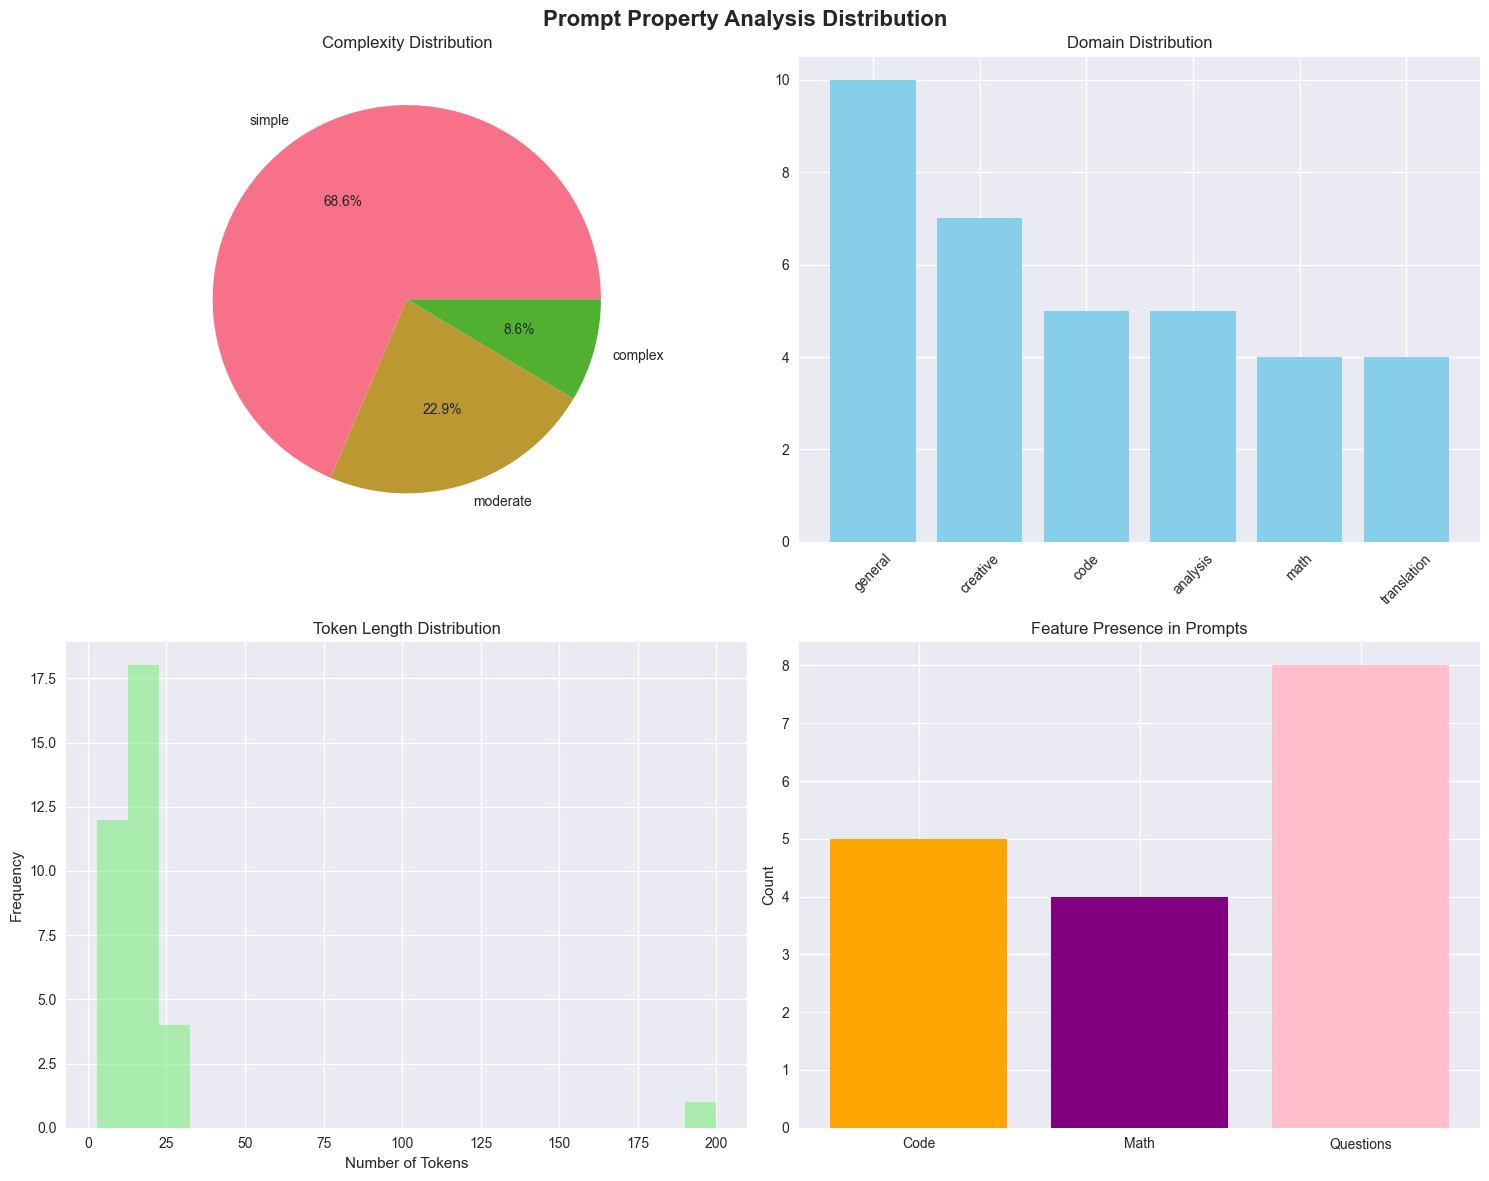


📊 SUMMARY STATISTICS
Average token length: 19.2
Average word count: 11.9
Prompts with code: 5/35 (14.3%)
Prompts with math: 4/35 (11.4%)
Prompts with questions: 8/35 (22.9%)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Prompt Property Analysis Distribution', fontsize=16, fontweight='bold')

# 1. Complexity distribution
complexity_counts = df['complexity'].value_counts()
axes[0, 0].pie(complexity_counts.values, labels=complexity_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Complexity Distribution')

# 2. Domain distribution
domain_counts = df['domain'].value_counts()
axes[0, 1].bar(domain_counts.index, domain_counts.values, color='skyblue')
axes[0, 1].set_title('Domain Distribution')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Token length distribution
axes[1, 0].hist(df['length_tokens'], bins=20, color='lightgreen', alpha=0.7)
axes[1, 0].set_title('Token Length Distribution')
axes[1, 0].set_xlabel('Number of Tokens')
axes[1, 0].set_ylabel('Frequency')

# 4. Feature presence
features = ['has_code', 'has_math', 'has_questions']
feature_counts = [df[feature].sum() for feature in features]
feature_labels = ['Code', 'Math', 'Questions']
axes[1, 1].bar(feature_labels, feature_counts, color=['orange', 'purple', 'pink'])
axes[1, 1].set_title('Feature Presence in Prompts')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n📊 SUMMARY STATISTICS")
print("=" * 50)
print(f"Average token length: {df['length_tokens'].mean():.1f}")
print(f"Average word count: {df['length_words'].mean():.1f}")
print(f"Prompts with code: {df['has_code'].sum()}/{len(df)} ({df['has_code'].mean()*100:.1f}%)")
print(f"Prompts with math: {df['has_math'].sum()}/{len(df)} ({df['has_math'].mean()*100:.1f}%)")
print(f"Prompts with questions: {df['has_questions'].sum()}/{len(df)} ({df['has_questions'].mean()*100:.1f}%)")


## 6. Routing Strategy Comparison <a id="routing"></a>


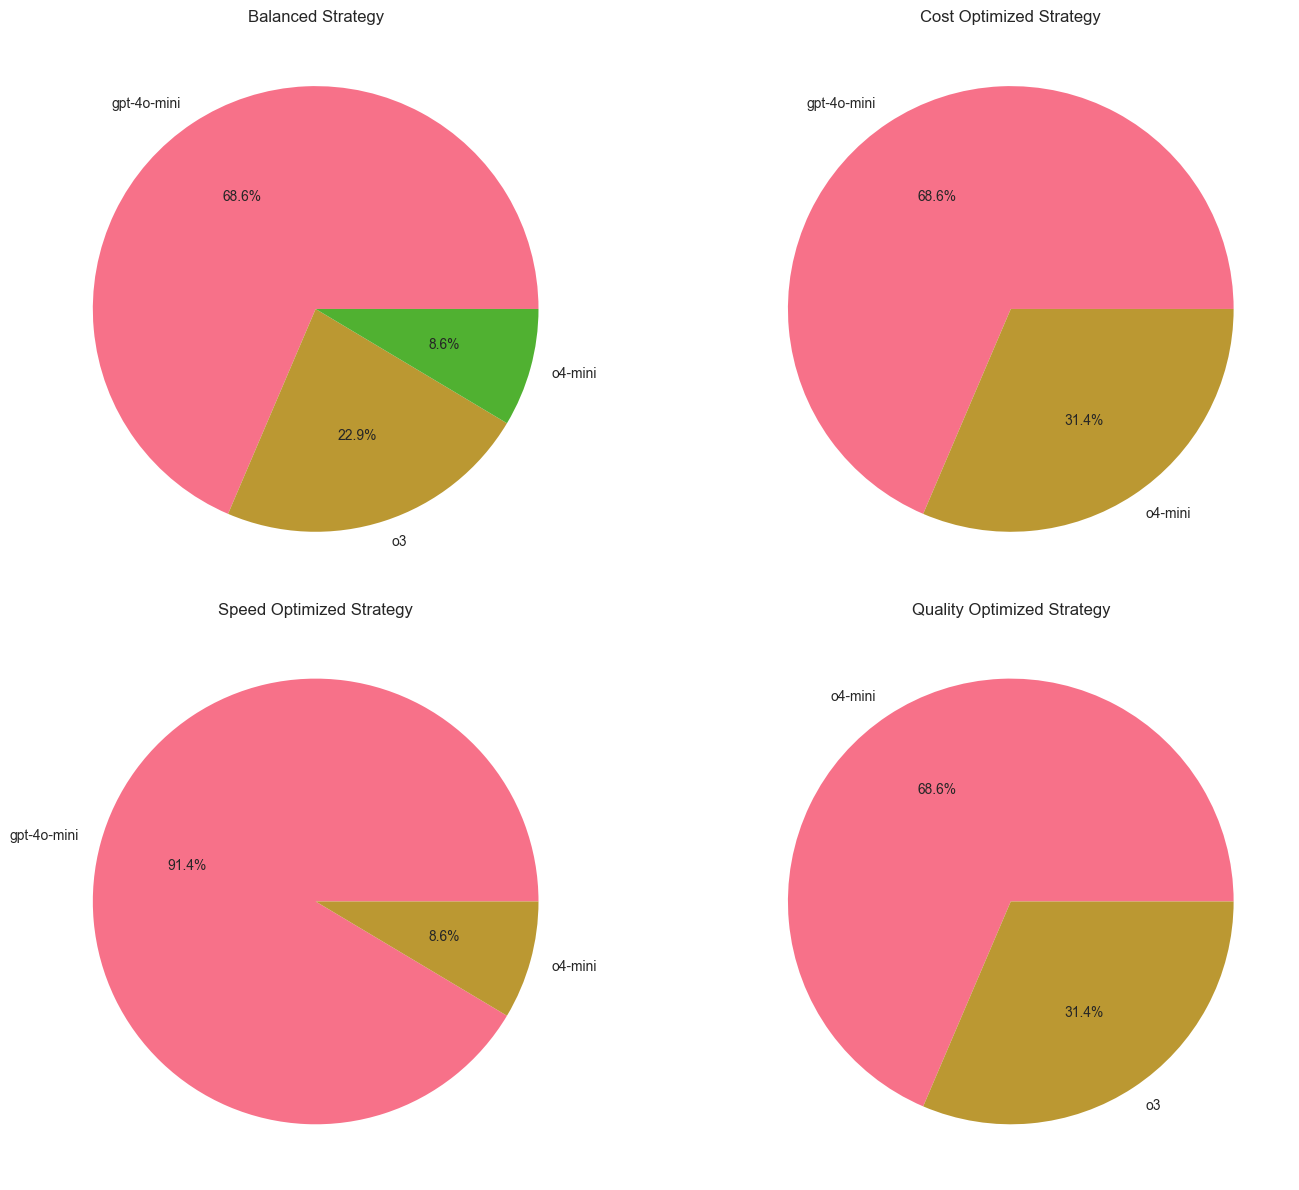


🤖 MODEL SELECTION MATRIX
             balanced_model  cost_optimized_model  speed_optimized_model  \
gpt-4o-mini              24                    24                     32   
o3                        8                     0                      0   
o4-mini                   3                    11                      3   

             quality_optimized_model  
gpt-4o-mini                        0  
o3                                11  
o4-mini                           24  

📈 ROUTING CONSISTENCY ANALYSIS:
Balanced            : gpt-4o-mini (68.6% usage)
Cost Optimized      : gpt-4o-mini (68.6% usage)
Speed Optimized     : gpt-4o-mini (91.4% usage)
Quality Optimized   : o4-mini (68.6% usage)


In [6]:
# Analyze routing decisions across different strategies
routing_strategies = ['balanced_model', 'cost_optimized_model', 'speed_optimized_model', 'quality_optimized_model']
strategy_names = ['Balanced', 'Cost Optimized', 'Speed Optimized', 'Quality Optimized']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (strategy, name) in enumerate(zip(routing_strategies, strategy_names)):
    model_counts = df[strategy].value_counts()
    axes[i].pie(model_counts.values, labels=model_counts.index, autopct='%1.1f%%')
    axes[i].set_title(f'{name} Strategy')

plt.tight_layout()
plt.show()

print("\n🤖 MODEL SELECTION MATRIX")
print("=" * 80)
model_matrix = df[routing_strategies].apply(pd.Series.value_counts, axis=0).fillna(0).astype(int)
print(model_matrix)

print(f"\n📈 ROUTING CONSISTENCY ANALYSIS:")
print("=" * 50)
for strategy, name in zip(routing_strategies, strategy_names):
    most_used_model = df[strategy].mode()[0]
    usage_pct = (df[strategy] == most_used_model).mean() * 100
    print(f"{name:<20}: {most_used_model} ({usage_pct:.1f}% usage)")


## 7. Cost and Performance Analysis <a id="cost"></a>


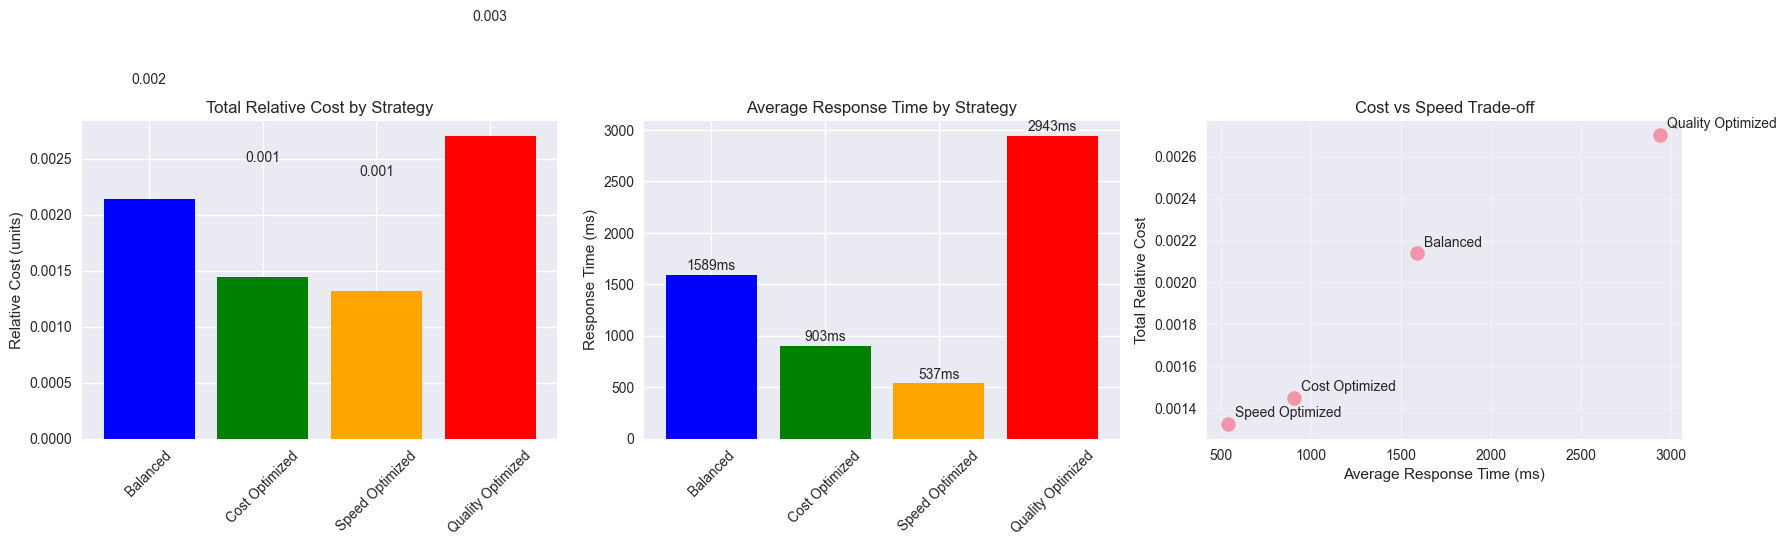


💰 STRATEGY PERFORMANCE SUMMARY
Balanced            : Cost baseline, Speed baseline
Cost Optimized      : Cost -32.3%, Speed 43.2% faster
Speed Optimized     : Cost -38.2%, Speed 66.2% faster
Quality Optimized   : Cost +26.4%, Speed 85.3% slower


In [7]:
def calculate_strategy_metrics(df, strategy_column):
    """Calculate total cost and response time for a routing strategy"""
    total_cost = 0
    total_response_time = 0
    cost_breakdown = {}
    
    for _, row in df.iterrows():
        model = row[strategy_column]
        tokens = row['length_tokens']
        model_config = analyzer.get_model_info(model)
        
        if 'input_cost_per_1k_tokens' in model_config and 'output_cost_per_1k_tokens' in model_config:
            avg_cost_per_1k = (model_config['input_cost_per_1k_tokens'] + model_config['output_cost_per_1k_tokens']) / 2
        else:
            print(f"Warning: Model {model} does not have a pricing structure")
            print(f"Falling back to default cost of 0.001")
            avg_cost_per_1k = 0.001
        
        prompt_cost = (tokens / 1000) * avg_cost_per_1k
        total_cost += prompt_cost
        
        # Calculate response time
        response_time = model_config['avg_response_time_ms']
        total_response_time += response_time
        
        # Track cost breakdown by model
        if model not in cost_breakdown:
            cost_breakdown[model] = 0
        cost_breakdown[model] += prompt_cost
    
    avg_response_time = total_response_time / len(df)
    return total_cost, avg_response_time, cost_breakdown

# Calculate metrics for each strategy
strategy_metrics = {}
for strategy, name in zip(routing_strategies, strategy_names):
    total_cost, avg_time, breakdown = calculate_strategy_metrics(df, strategy)
    strategy_metrics[name] = {
        'total_cost': total_cost, 
        'avg_response_time': avg_time,
        'breakdown': breakdown
    }

# Visualize cost and performance comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# 1. Total relative costs comparison
total_costs = [strategy_metrics[name]['total_cost'] for name in strategy_names]
bars1 = ax1.bar(strategy_names, total_costs, color=['blue', 'green', 'orange', 'red'])
ax1.set_title('Total Relative Cost by Strategy')
ax1.set_ylabel('Relative Cost (units)')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, cost in zip(bars1, total_costs):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{cost:.3f}', ha='center', va='bottom', fontsize=10)

# 2. Average response times
response_times = [strategy_metrics[name]['avg_response_time'] for name in strategy_names]
bars2 = ax2.bar(strategy_names, response_times, color=['blue', 'green', 'orange', 'red'])
ax2.set_title('Average Response Time by Strategy')
ax2.set_ylabel('Response Time (ms)')
ax2.tick_params(axis='x', rotation=45)

# Add value labels
for bar, time in zip(bars2, response_times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{time:.0f}ms', ha='center', va='bottom', fontsize=10)

# 3. Cost vs Speed trade-off
ax3.scatter(response_times, total_costs, s=100, alpha=0.7)
for i, name in enumerate(strategy_names):
    ax3.annotate(name, (response_times[i], total_costs[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=10)
ax3.set_xlabel('Average Response Time (ms)')
ax3.set_ylabel('Total Relative Cost')
ax3.set_title('Cost vs Speed Trade-off')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💰 STRATEGY PERFORMANCE SUMMARY")
print("=" * 60)
balanced_cost = strategy_metrics['Balanced']['total_cost']
balanced_time = strategy_metrics['Balanced']['avg_response_time']

for name in strategy_names:
    cost = strategy_metrics[name]['total_cost']
    time = strategy_metrics[name]['avg_response_time']
    cost_saving = (cost - balanced_cost) / balanced_cost * 100
    time_saving = (time - balanced_time) / balanced_time * 100
    
    cost_text = f"{cost_saving:+.1f}%" if cost_saving != 0 else "baseline"
    if time_saving > 0:
        speed_text = f"{time_saving:.1f}% slower"
    elif time_saving < 0:
        speed_text = f"{abs(time_saving):.1f}% faster"
    else:
        speed_text = "baseline"
    
    print(f"{name:<20}: Cost {cost_text}, Speed {speed_text}")


## 8. Real-World Scenario Testing <a id="scenarios"></a>


In [8]:
real_world_scenarios = [
    {
        "scenario": "Customer Support - Simple FAQ",
        "prompt": "What are your business hours?",
        "expected_priority": "speed",
        "expected_model": "gpt-4o-mini",
        "rationale": "Simple query, needs fast response"
    },
    {
        "scenario": "Developer Assistant - Code Review",
        "prompt": "Review this Python code for security vulnerabilities: def login(username, password): query = f'SELECT * FROM users WHERE username = {username} AND password = {password}'",
        "expected_priority": "quality",
        "expected_model": "o3",
        "rationale": "Code analysis requires technical expertise"
    },
    {
        "scenario": "Emergency Support",
        "prompt": "URGENT: My production database is down and I'm getting connection timeouts. What should I check first?",
        "expected_priority": "speed",
        "expected_model": "gpt-4o-mini",
        "rationale": "Urgent query needs immediate response"
    },
    {
        "scenario": "Content Creation - Marketing",
        "prompt": "Create a comprehensive marketing strategy for a new SaaS product targeting small businesses, including positioning, messaging, channels, and budget allocation.",
        "expected_priority": "quality",
        "expected_model": "o3",
        "rationale": "Complex creative task requires high-quality output"
    },
    {
        "scenario": "Data Analysis Request",
        "prompt": "Analyze the correlation between customer acquisition cost and lifetime value across different marketing channels.",
        "expected_priority": "balanced",
        "expected_model": "o4-mini",
        "rationale": "Technical analysis with moderate complexity"
    },
    {
        "scenario": "Math Problem Solving",
        "prompt": "Calculate the compound annual growth rate (CAGR) for an investment that grows from $10,000 to $25,000 over 7 years.",
        "expected_priority": "balanced",
        "expected_model": "o4-mini",
        "rationale": "Mathematical calculation requires precision"
    },
    {
        "scenario": "High-Volume Chat",
        "prompt": "Hello, how are you today?",
        "expected_priority": "cost",
        "expected_model": "gpt-4o-mini",
        "rationale": "Simple greeting, cost optimization priority"
    },
    {
        "scenario": "Complex Research Analysis",
        "prompt": "Analyze the impact of quantum computing on current cryptographic standards and provide recommendations for future-proofing enterprise security systems.",
        "expected_priority": "quality",
        "expected_model": "o3",
        "rationale": "Complex technical analysis requiring advanced reasoning"
    },
    {
        "scenario": "API Documentation",
        "prompt": "Generate API documentation for a REST endpoint that handles user authentication with JWT tokens.",
        "expected_priority": "balanced",
        "expected_model": "o4-mini",
        "rationale": "Technical documentation with moderate complexity"
    },
    {
        "scenario": "Quick Translation",
        "prompt": "Translate 'Hello, how can I help you?' to Spanish.",
        "expected_priority": "speed",
        "expected_model": "gpt-4o-mini",
        "rationale": "Simple translation task, speed priority"
    }
]

print("🌍 REAL-WORLD SCENARIO TESTING")
print("=" * 70)

scenario_results = []

for scenario in real_world_scenarios:
    # Test with different priorities
    priorities = ['balanced', 'cost', 'speed', 'quality']
    results = {}
    
    for priority in priorities:
        if priority == 'balanced':
            analysis = analyzer.analyze_prompt(scenario['prompt'])
        else:
            analysis = analyzer.analyze_prompt(scenario['prompt'], {'priority': priority})
        results[priority] = analysis.recommended_model
    
    # Get detailed analysis for balanced approach
    balanced_analysis = analyzer.analyze_prompt(scenario['prompt'])
    
    scenario_results.append({
        'scenario': scenario['scenario'],
        'prompt': scenario['prompt'][:100] + '...',
        'complexity': balanced_analysis.complexity.value,
        'domain': balanced_analysis.domain.value,
        'has_code': balanced_analysis.has_code,
        'has_math': balanced_analysis.has_math,
        'urgency': len(balanced_analysis.urgency_indicators) > 0,
        **results
    })
    
    print(f"\n📋 {scenario['scenario']}")
    print(f"Prompt: {scenario['prompt'][:100]}...")
    print(f"Analysis: {balanced_analysis.complexity.value} complexity, {balanced_analysis.domain.value} domain")
    print(f"Features: Code={balanced_analysis.has_code}, Math={balanced_analysis.has_math}, Urgent={len(balanced_analysis.urgency_indicators) > 0}")
    print(f"Routing Results:")
    for priority in priorities:
        model = results[priority]
        expected_match = "✅" if (priority == scenario['expected_priority'] and model == scenario['expected_model']) else ""
        print(f"  📊 {priority.capitalize():<12}: {model} {expected_match}")
    print(f"Expected: {scenario['expected_model']} ({scenario['rationale']})")


scenario_df = pd.DataFrame(scenario_results)
print("\n📊 Scenario Testing Summary:")
print(scenario_df[['scenario', 'complexity', 'domain', 'balanced', 'speed', 'quality']].to_string(index=False))

# Calculate total correct and incorrect routing decisions
total_scenarios = len(scenario_results)
correct = 0
incorrect = 0
detailed_results = []

for scenario in scenario_results:
    expected_priority = None
    expected_model = None
    # Find the original scenario dict to get expected values
    for s in real_world_scenarios:
        if s['scenario'] == scenario['scenario']:
            expected_priority = s['expected_priority']
            expected_model = s['expected_model']
            break
    routed_model = scenario[expected_priority]
    if routed_model == expected_model:
        correct += 1
        detailed_results.append((scenario['scenario'], True, expected_priority, expected_model, routed_model))
    else:
        incorrect += 1
        detailed_results.append((scenario['scenario'], False, expected_priority, expected_model, routed_model))

print(f"\n✅ Routing Accuracy: {correct}/{total_scenarios} correct, {incorrect} incorrect ({correct/total_scenarios:.1%})")

# Analysis of results
if correct == total_scenarios:
    print("🎉 All scenarios were routed correctly. The smart routing logic is robust across the tested real-world cases.")
elif correct > total_scenarios * 0.8:
    print("👍 The majority of scenarios were routed correctly, indicating strong alignment between routing logic and business expectations. Review the incorrect cases for potential edge-case improvements.")
else:
    print("⚠️ Significant number of routing mismatches detected. Review the routing logic, especially for scenarios where the expected model was not selected. Consider enhancing feature detection, model capability mapping, or business rule alignment.")

# Optionally, print a table of incorrect cases for further analysis
if incorrect > 0:
    print("\n❌ Incorrect Routing Cases:")
    for scenario_name, is_correct, exp_priority, exp_model, routed_model in detailed_results:
        if not is_correct:
            print(f"  - Scenario: {scenario_name} | Expected: {exp_model} ({exp_priority}) | Routed: {routed_model}")


🌍 REAL-WORLD SCENARIO TESTING

📋 Customer Support - Simple FAQ
Prompt: What are your business hours?...
Analysis: simple complexity, general domain
Features: Code=False, Math=False, Urgent=False
Routing Results:
  📊 Balanced    : gpt-4o-mini 
  📊 Cost        : gpt-4o-mini 
  📊 Speed       : gpt-4o-mini ✅
  📊 Quality     : o4-mini 
Expected: gpt-4o-mini (Simple query, needs fast response)

📋 Developer Assistant - Code Review
Prompt: Review this Python code for security vulnerabilities: def login(username, password): query = f'SELEC...
Analysis: moderate complexity, code domain
Features: Code=True, Math=False, Urgent=False
Routing Results:
  📊 Balanced    : o4-mini 
  📊 Cost        : o4-mini 
  📊 Speed       : o4-mini 
  📊 Quality     : o4-mini 
Expected: o3 (Code analysis requires technical expertise)

📋 Emergency Support
Prompt: URGENT: My production database is down and I'm getting connection timeouts. What should I check firs...
Analysis: simple complexity, general domain
Features: C

## 9. Rule-Based Model Performance Evaluation <a id="metrics"></a>

This section evaluates the performance of our rule-based routing system using appropriate metrics for classification and routing accuracy.


🎯 RULE-BASED ROUTING MODEL EVALUATION

1️⃣ ROUTING ACCURACY BY STRATEGY
----------------------------------------
  Balanced    : 1/10 correct (10.0%)
  Cost        : 1/10 correct (10.0%)
  Speed       : 3/10 correct (30.0%)
  Quality     : 1/10 correct (10.0%)

2️⃣ COMPLEXITY CLASSIFICATION ANALYSIS
----------------------------------------
Overall Complexity Classification Accuracy: 57.1%

Detailed Complexity Classification Report:
              precision    recall  f1-score   support

     complex       0.67      0.33      0.44         6
    moderate       0.75      0.38      0.50        16
      simple       0.50      0.92      0.65        13

    accuracy                           0.57        35
   macro avg       0.64      0.54      0.53        35
weighted avg       0.64      0.57      0.55        35


3️⃣ DOMAIN CLASSIFICATION ANALYSIS
----------------------------------------
Overall Domain Classification Accuracy: 82.9%

Detailed Domain Classification Report:
              precis

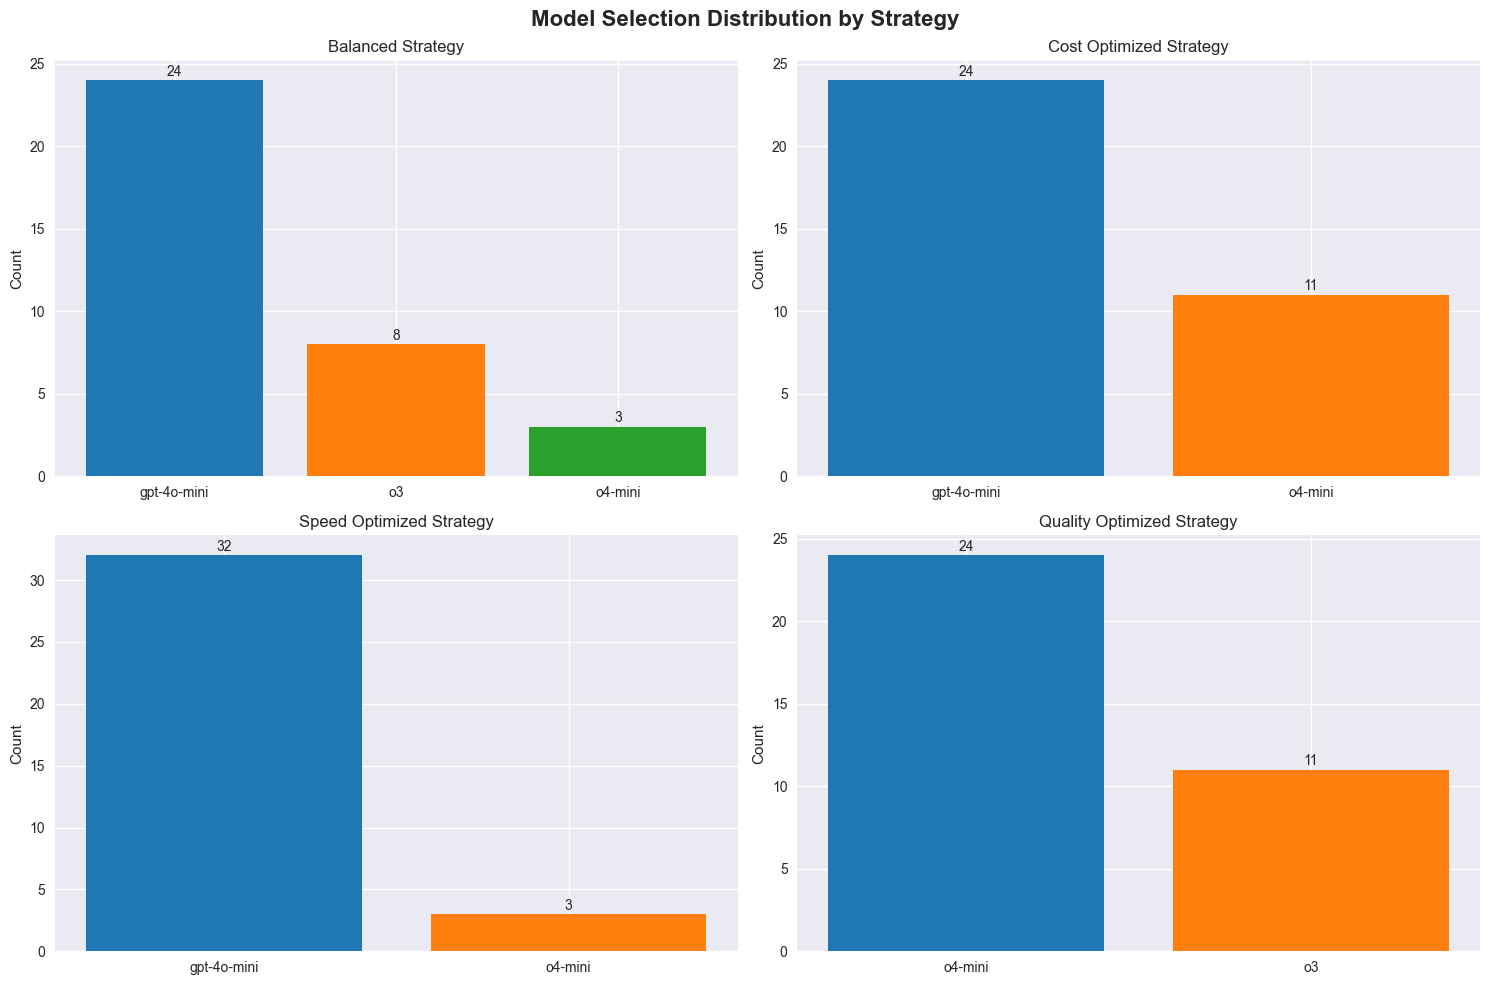


6️⃣ COST-EFFECTIVENESS ANALYSIS
----------------------------------------
Balanced            : $0.0001/prompt, 1589ms avg
Cost Optimized      : $0.0000/prompt, 903ms avg
Speed Optimized     : $0.0000/prompt, 537ms avg
Quality Optimized   : $0.0001/prompt, 2943ms avg

💡 Cost Efficiency Ratios (Cost per ms):
Balanced            : $0.000038 per second
Cost Optimized      : $0.000046 per second
Speed Optimized     : $0.000070 per second
Quality Optimized   : $0.000026 per second

7️⃣ ROUTING CONSISTENCY METRICS
----------------------------------------
Routing Consistency by Category (1.0 = perfectly consistent):
  Simple General Queries   : 1.00
  Code Generation          : 0.67
  Mathematical Problems    : 0.80
  Creative Writing         : 1.00
  Complex Analysis         : 0.80
  Translation Tasks        : 1.00
  Urgent/Real-time Queries : 0.75

Overall Routing Consistency: 0.86

✅ RULE-BASED MODEL EVALUATION COMPLETE


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from collections import Counter
import seaborn as sns

print("🎯 RULE-BASED ROUTING MODEL EVALUATION")
print("=" * 70)

# === 1. ROUTING ACCURACY ANALYSIS ===
print("\n1️⃣ ROUTING ACCURACY BY STRATEGY")
print("-" * 40)

strategies_to_evaluate = ['balanced', 'cost', 'speed', 'quality']
strategy_accuracy = {}

for strategy in strategies_to_evaluate:
    correct_routes = 0
    total_routes = len(real_world_scenarios)
    
    for i, scenario in enumerate(real_world_scenarios):
        expected_priority = scenario['expected_priority']
        expected_model = scenario['expected_model']
        
        # Get the actual routing decision for this strategy
        actual_model = scenario_results[i][strategy]
        
        # Check if the routing matches expectation when priorities align
        if strategy == expected_priority and actual_model == expected_model:
            correct_routes += 1
    
    accuracy = correct_routes / total_routes if total_routes > 0 else 0
    strategy_accuracy[strategy] = accuracy
    print(f"  {strategy.capitalize():<12}: {correct_routes}/{total_routes} correct ({accuracy:.1%})")

# === 2. COMPLEXITY CLASSIFICATION ACCURACY ===
print("\n2️⃣ COMPLEXITY CLASSIFICATION ANALYSIS")
print("-" * 40)

# Expected complexity based on prompt categories
expected_complexity_mapping = {
    "Simple General Queries": "simple",
    "Code Generation": "moderate", 
    "Mathematical Problems": "moderate",
    "Creative Writing": "moderate",
    "Complex Analysis": "complex",
    "Translation Tasks": "simple",
    "Urgent/Real-time Queries": "simple",
    "Long Context Queries": "complex"
}

# Get actual vs expected complexity
actual_complexity = df['complexity'].tolist()
expected_complexity = [expected_complexity_mapping.get(cat, "moderate") for cat in df['category']]

complexity_accuracy = accuracy_score(expected_complexity, actual_complexity)
print(f"Overall Complexity Classification Accuracy: {complexity_accuracy:.1%}")

# Detailed classification report
print("\nDetailed Complexity Classification Report:")
print(classification_report(expected_complexity, actual_complexity, zero_division=0))

# === 3. DOMAIN CLASSIFICATION ANALYSIS ===
print("\n3️⃣ DOMAIN CLASSIFICATION ANALYSIS")
print("-" * 40)

# Expected domains based on categories
expected_domain_mapping = {
    "Simple General Queries": "general",
    "Code Generation": "code", 
    "Mathematical Problems": "math",
    "Creative Writing": "creative",
    "Complex Analysis": "analysis",
    "Translation Tasks": "translation",
    "Urgent/Real-time Queries": "general",
    "Long Context Queries": "analysis"
}

actual_domains = df['domain'].tolist()
expected_domains = [expected_domain_mapping.get(cat, "general") for cat in df['category']]

domain_accuracy = accuracy_score(expected_domains, actual_domains)
print(f"Overall Domain Classification Accuracy: {domain_accuracy:.1%}")

print("\nDetailed Domain Classification Report:")
print(classification_report(expected_domains, actual_domains, zero_division=0))

# === 4. FEATURE DETECTION ACCURACY ===
print("\n4️⃣ FEATURE DETECTION ANALYSIS")
print("-" * 40)

# Code detection accuracy
code_categories = ["Code Generation"]
expected_code = [1 if cat in code_categories else 0 for cat in df['category']]
actual_code = df['has_code'].astype(int).tolist()
code_accuracy = accuracy_score(expected_code, actual_code)
print(f"Code Detection Accuracy: {code_accuracy:.1%}")

# Math detection accuracy  
math_categories = ["Mathematical Problems"]
expected_math = [1 if cat in math_categories else 0 for cat in df['category']]
actual_math = df['has_math'].astype(int).tolist()
math_accuracy = accuracy_score(expected_math, actual_math)
print(f"Math Detection Accuracy: {math_accuracy:.1%}")

# === 5. MODEL SELECTION DISTRIBUTION ===
print("\n5️⃣ MODEL SELECTION DISTRIBUTION")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Selection Distribution by Strategy', fontsize=16, fontweight='bold')

strategies = ['balanced_model', 'cost_optimized_model', 'speed_optimized_model', 'quality_optimized_model']
strategy_titles = ['Balanced', 'Cost Optimized', 'Speed Optimized', 'Quality Optimized']

for i, (strategy, title) in enumerate(zip(strategies, strategy_titles)):
    row, col = i // 2, i % 2
    model_counts = df[strategy].value_counts()
    
    # Create bar plot
    bars = axes[row, col].bar(model_counts.index, model_counts.values, 
                             color=['#1f77b4', '#ff7f0e', '#2ca02c'][:len(model_counts)])
    axes[row, col].set_title(f'{title} Strategy')
    axes[row, col].set_ylabel('Count')
    
    # Add value labels on bars
    for bar, count in zip(bars, model_counts.values):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                           f'{count}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# === 6. COST-EFFECTIVENESS METRICS ===
print("\n6️⃣ COST-EFFECTIVENESS ANALYSIS")
print("-" * 40)

# Calculate cost per prompt for each strategy
for strategy_name in strategy_names:
    total_cost = strategy_metrics[strategy_name]['total_cost']
    avg_cost_per_prompt = total_cost / len(df)
    avg_response_time = strategy_metrics[strategy_name]['avg_response_time']
    
    print(f"{strategy_name:<20}: ${avg_cost_per_prompt:.4f}/prompt, {avg_response_time:.0f}ms avg")

# Cost efficiency ratio (lower is better)
print("\n💡 Cost Efficiency Ratios (Cost per ms):")
for strategy_name in strategy_names:
    total_cost = strategy_metrics[strategy_name]['total_cost']
    avg_response_time = strategy_metrics[strategy_name]['avg_response_time']
    efficiency_ratio = (total_cost / len(df)) / (avg_response_time / 1000)  # cost per second
    print(f"{strategy_name:<20}: ${efficiency_ratio:.6f} per second")

# === 7. ROUTING CONSISTENCY ANALYSIS ===
print("\n7️⃣ ROUTING CONSISTENCY METRICS")
print("-" * 40)

# Calculate how often the same prompt type gets routed to the same model
consistency_by_category = {}
for category in df['category'].unique():
    category_data = df[df['category'] == category]
    if len(category_data) > 1:
        # Check consistency across different strategies
        balanced_models = category_data['balanced_model'].unique()
        consistency_score = 1 - (len(balanced_models) - 1) / len(category_data)
        consistency_by_category[category] = consistency_score

print("Routing Consistency by Category (1.0 = perfectly consistent):")
for category, score in consistency_by_category.items():
    print(f"  {category:<25}: {score:.2f}")

avg_consistency = np.mean(list(consistency_by_category.values()))
print(f"\nOverall Routing Consistency: {avg_consistency:.2f}")

print("\n✅ RULE-BASED MODEL EVALUATION COMPLETE")
print("=" * 70)
